# Multi-agent impact in AIDev v5

**Purpose.** Reproduce the first evidence pass for three research questions: the
sequential multi-agent onset, outcome-conditioned switching, and recovery after a
closed-unmerged pull request. All estimates are exploratory associations.

## Context and method

A transition links each mature current PR to the latest earlier PR in the same
repository whose outcome was already known when the current PR opened. The primary
ledger begins at observed second-agent entry, keeps the first current PR per prior
episode, and measures merge within 30 days. The source dataset
is pinned to Hugging Face revision
`37bbe1533e26cc1e1374917dba1186d1c8a4dc81`.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUT = PROJECT_ROOT / "outputs"
TABLES = OUTPUT / "tables"
FIGURES = OUTPUT / "figures"

required = [
    TABLES / "data_quality.json",
    TABLES / "rq2_switching_response.csv",
    FIGURES / "rq2_switching_response.png",
]
missing = [str(path) for path in required if not path.exists()]
assert not missing, f"Run scripts/analysis/run_exploration.py first; missing: {missing}"

## Data quality and scope

In [2]:
quality = json.loads((TABLES / "data_quality.json").read_text(encoding="utf-8"))
overview = pd.Series(quality["overview"], name="value").to_frame()
display(overview)
display(pd.DataFrame(quality["agent_counts"]))

,value
rows,7685281
unique_ids,7685281
repositories,961168
agents,6
first_created,2024-12-24T00:23:09+00:00
last_created,2026-03-31T23:59:59+00:00
null_repo_url,0
null_agent,0
null_created,0
open_or_null_closed,735168


,agent,prs,repos
0,OpenAI_Codex,3844602,355920
1,Copilot,1581924,347971
2,Claude_Code,1567100,174038
3,Cursor,317453,81915
4,Google_Jules,296411,41125
5,Devin,77791,10321


The corpus contains six labeled agents. Results should not be interpreted as a
randomized comparison: repositories, tasks, contributor identities, and automation
policies may jointly affect both agent switching and merge outcomes.

## RQ1 — How does sequential multi-agent participation begin?

,event_index,n,merge_rate,median_resolution_hours,merge_ci_half_width
0,-10,8087,0.851614,0.239722,0.007748
1,-9,8793,0.855339,0.250833,0.007352
2,-8,9604,0.852666,0.252500,0.007089
3,-7,10619,0.853094,0.266111,0.006733
4,-6,11922,0.848431,0.260833,0.006437
5,-5,13583,0.835751,0.270278,0.006231
6,-4,15832,0.829586,0.289722,0.005857
7,-3,19044,0.818683,0.308056,0.005472
8,-2,24725,0.795228,0.343056,0.005030
9,-1,38418,0.757562,0.532639,0.004285


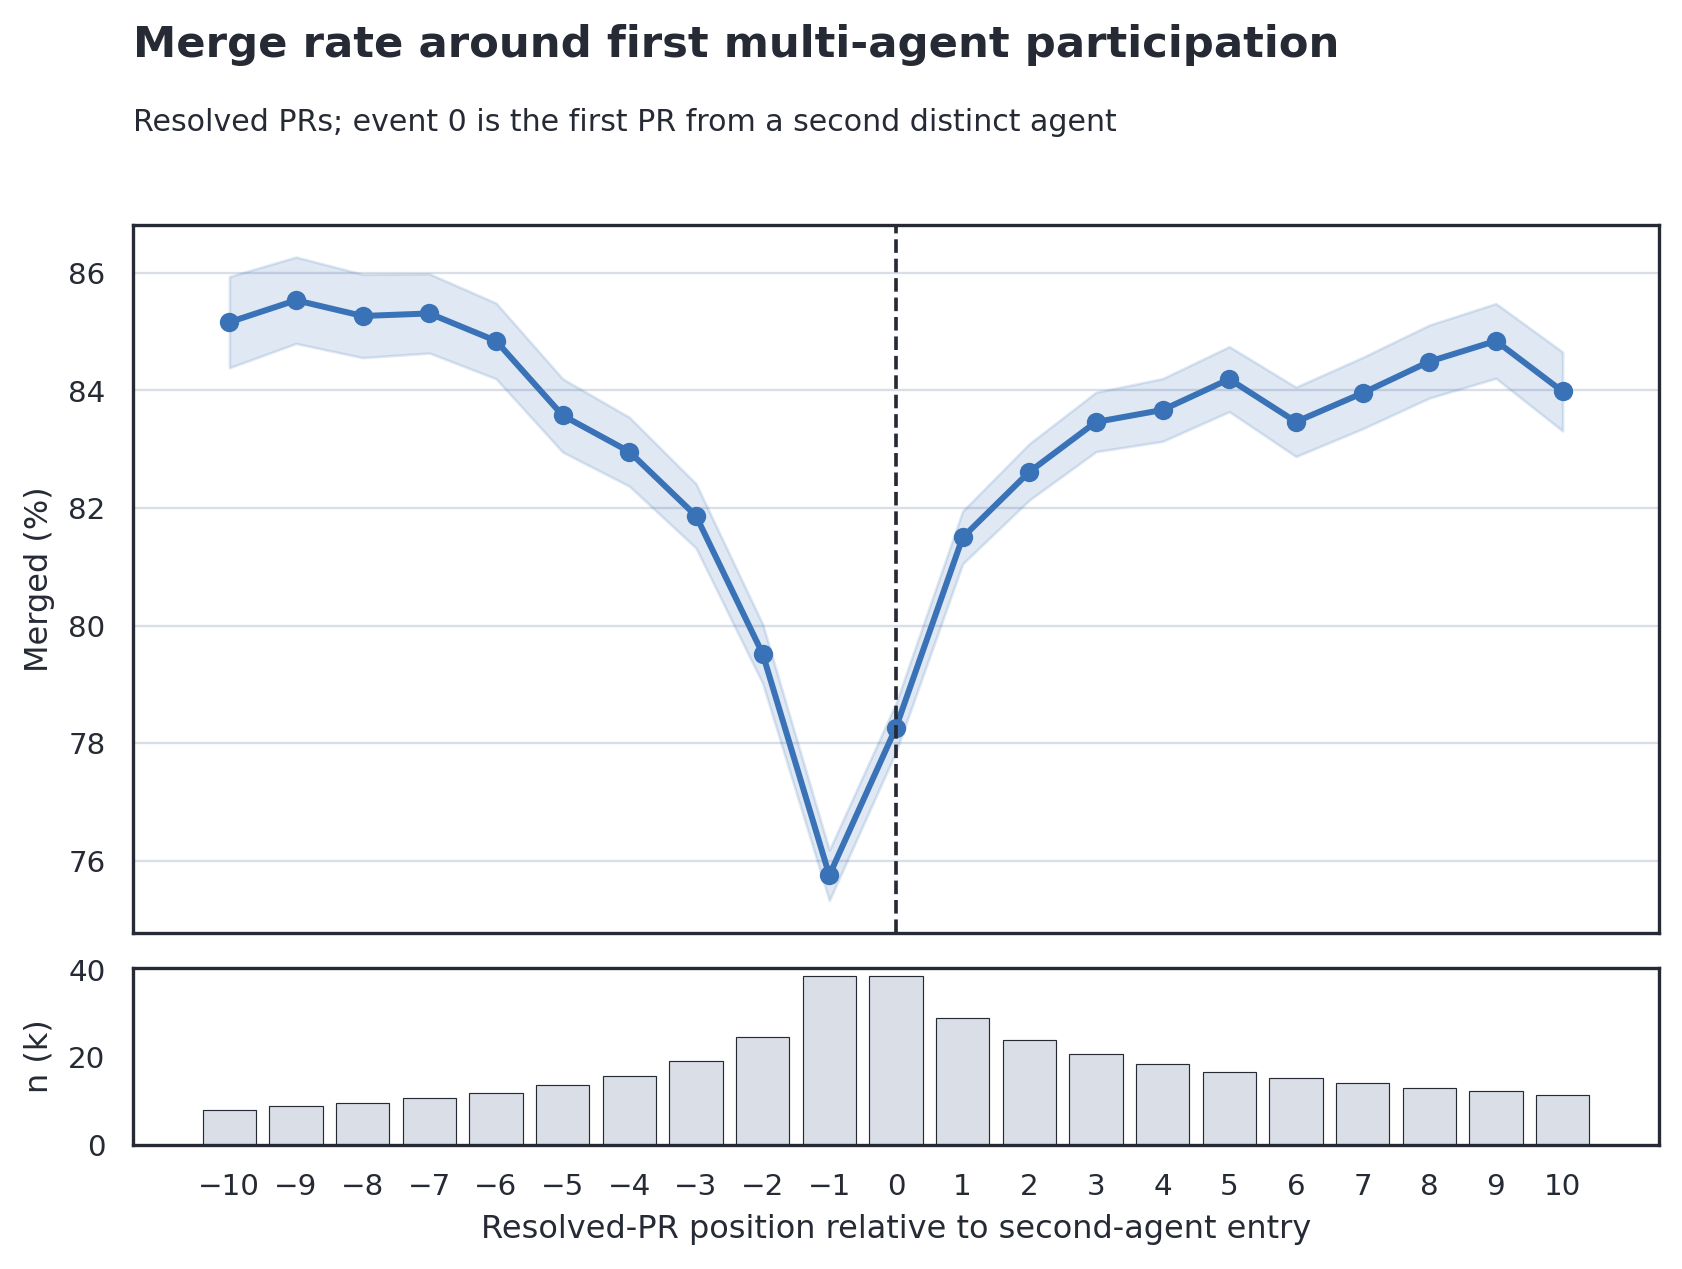

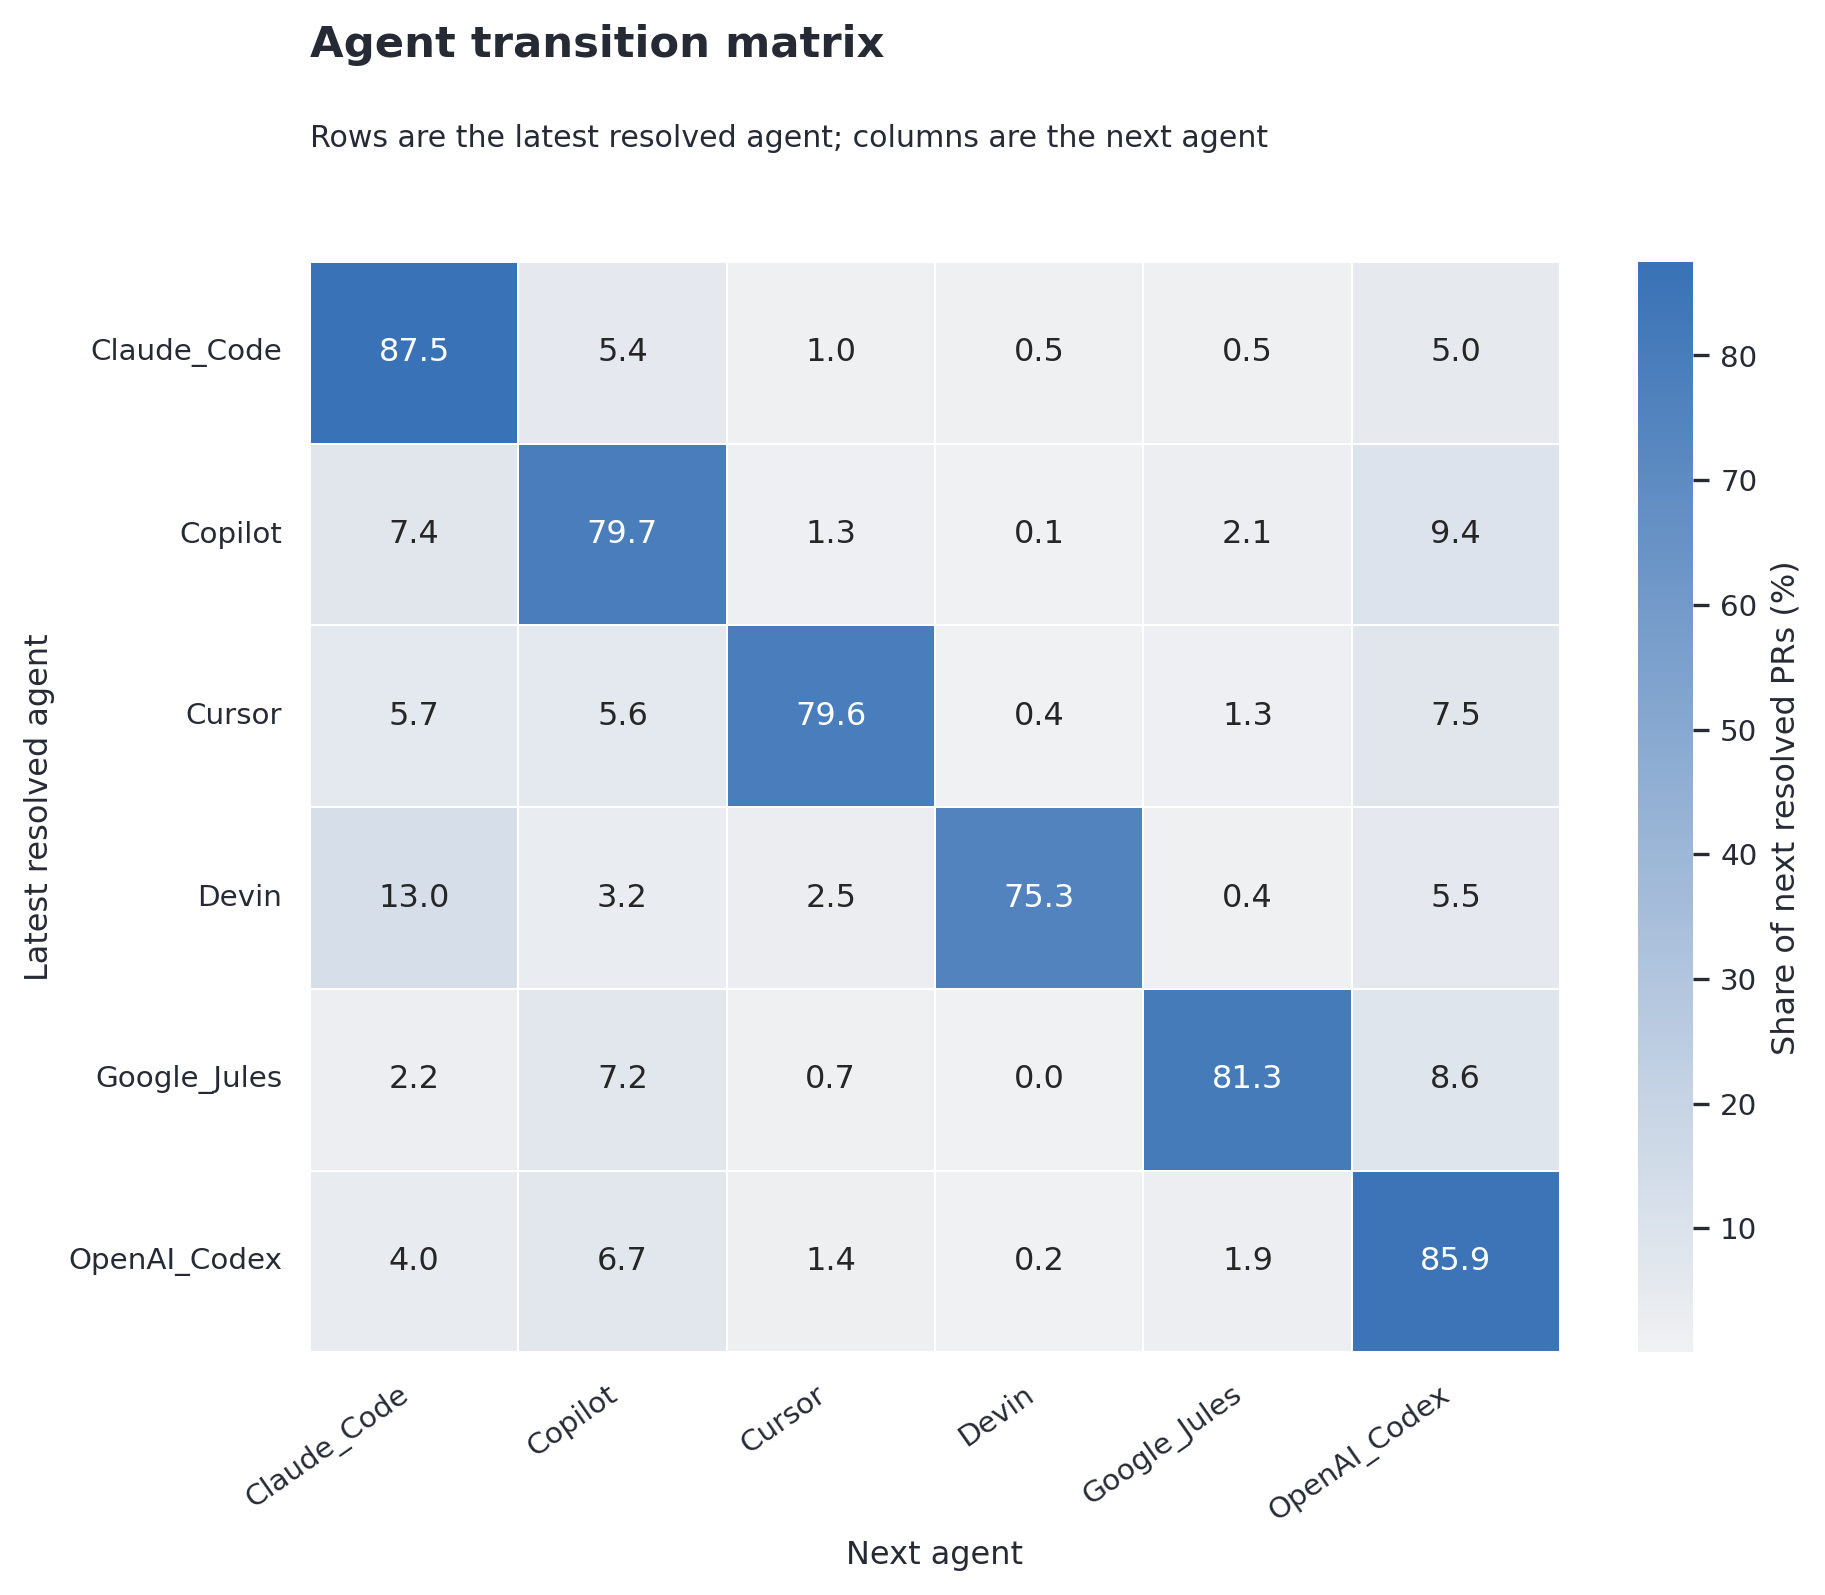

In [3]:
event = pd.read_csv(TABLES / "rq1_event_study.csv")
display(event)
display(Image(filename=str(FIGURES / "rq1_event_study.png")))
display(Image(filename=str(FIGURES / "rq1_transition_matrix.png")))

The event profile is descriptive. The strong decline before second-agent entry shows
endogenous timing and possible regression to the mean; the rebound is not an impact
estimate. The transition matrix is topology evidence and belongs in an appendix.

## RQ2 — Does a closed-unmerged outcome precede agent switching?

,prior_outcome,n,repositories,switch_percent
0,Prior closed-unmerged,49733,14115,31.236805
1,Prior merged,416734,28302,14.163471


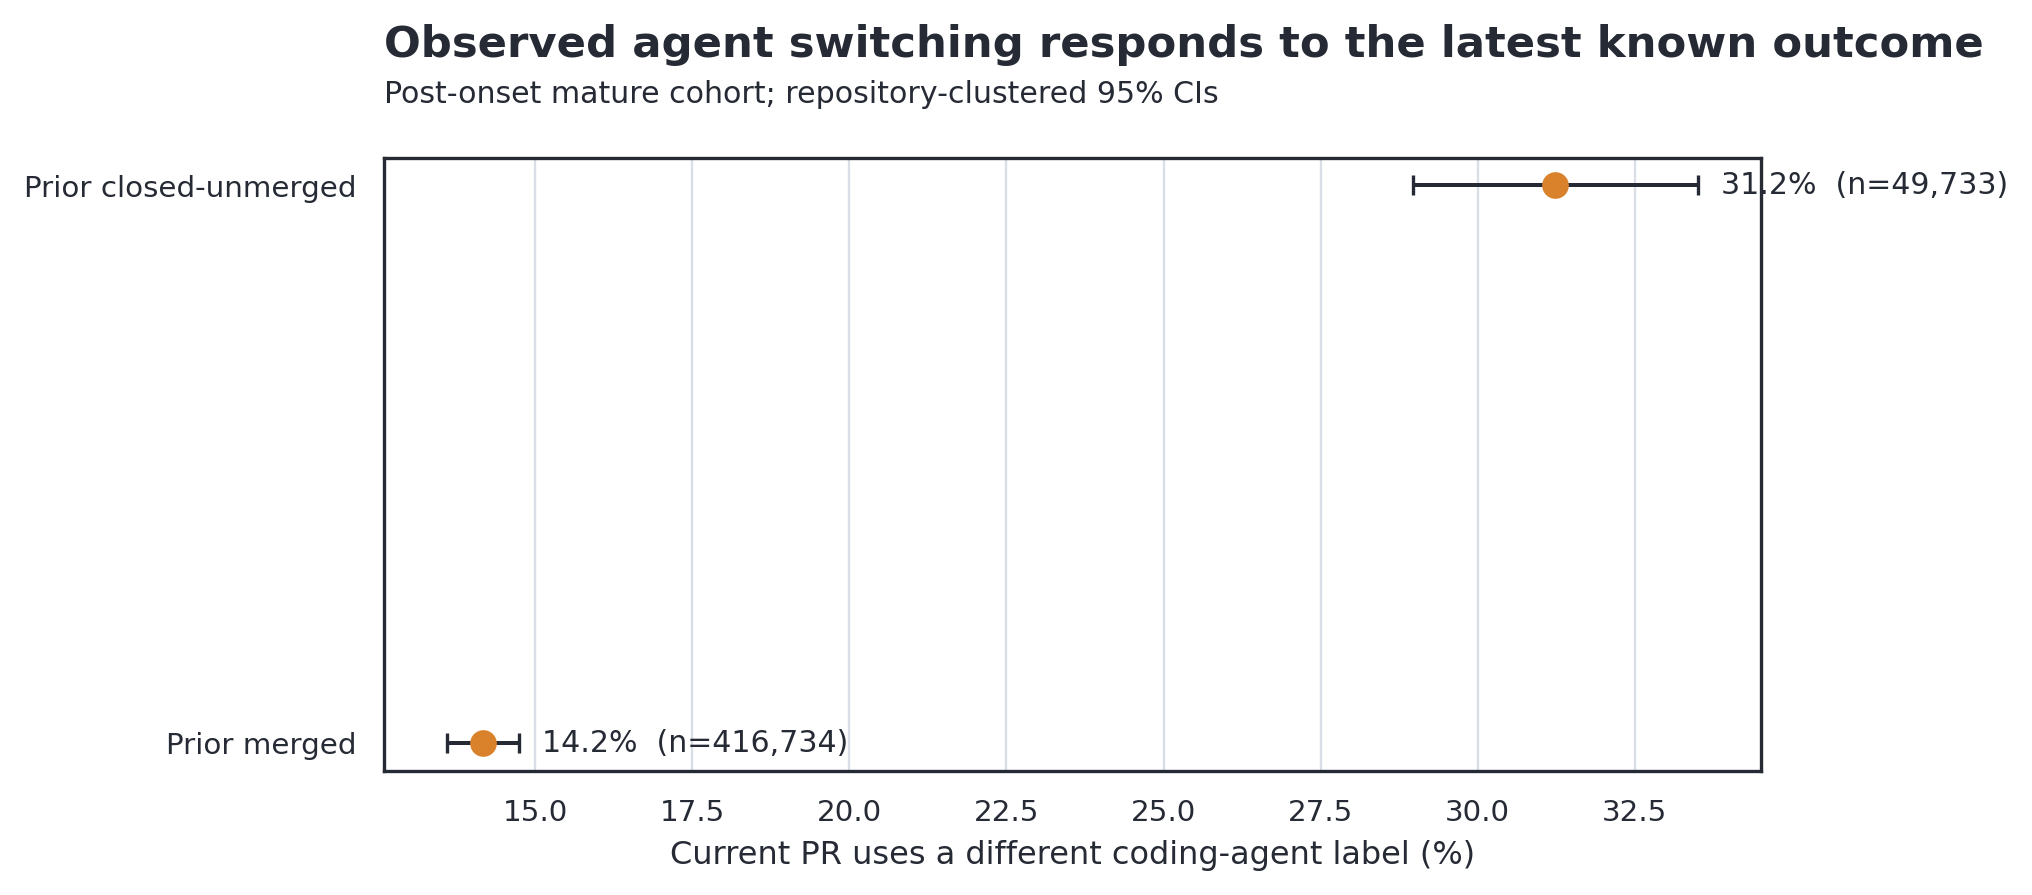

In [4]:
switching = pd.read_csv(TABLES / "rq2_switching_response.csv")
switching["switch_percent"] = 100 * switching["switch_rate"]
display(switching[["prior_outcome", "n", "repositories", "switch_percent"]])
display(Image(filename=str(FIGURES / "rq2_switching_response.png")))

A higher switching rate after closed-unmerged outcomes is consistent with behavioral
response, but cannot identify who selected the tool or whether agent reputation caused
the transition. Agent changes frequently coincide with contributor changes.

## RQ3 — When is switching associated with 30-day integration?

,prior_outcome,transition_type,n,merge_rate
0,Prior closed-unmerged,Same agent,34198,0.584742
1,Prior closed-unmerged,Switched agent,15535,0.633988
2,Prior merged,Same agent,357710,0.902197
3,Prior merged,Switched agent,59024,0.768704


,star_bin,stay_n,switch_n,stay_merge_rate,switch_merge_rate,effect_pp,ci_low_pp,ci_high_pp
0,0,9038,5014,0.652025,0.687475,3.545029,1.929312,5.160745
1,1–9,9254,4276,0.656041,0.694808,3.876760,2.190991,5.562530
2,10–99,5503,1861,0.463565,0.636217,17.265176,14.713000,19.817352
3,100+,10287,4342,0.525712,0.510594,-1.511787,-3.284363,0.260790
4,Missing,116,42,0.637931,0.714286,7.635468,-8.586715,23.857651


,term,estimate,std_error,p_value,ci_low,ci_high,n,repositories,r_squared_within
1,switched,0.064773,0.007517,6.891958e-18,0.050039,0.079506,466467,31323,0.01713
28,switched_after_prior_merged,-0.042933,0.002441,2.849581e-69,-0.047717,-0.038150,466467,31323,0.01713


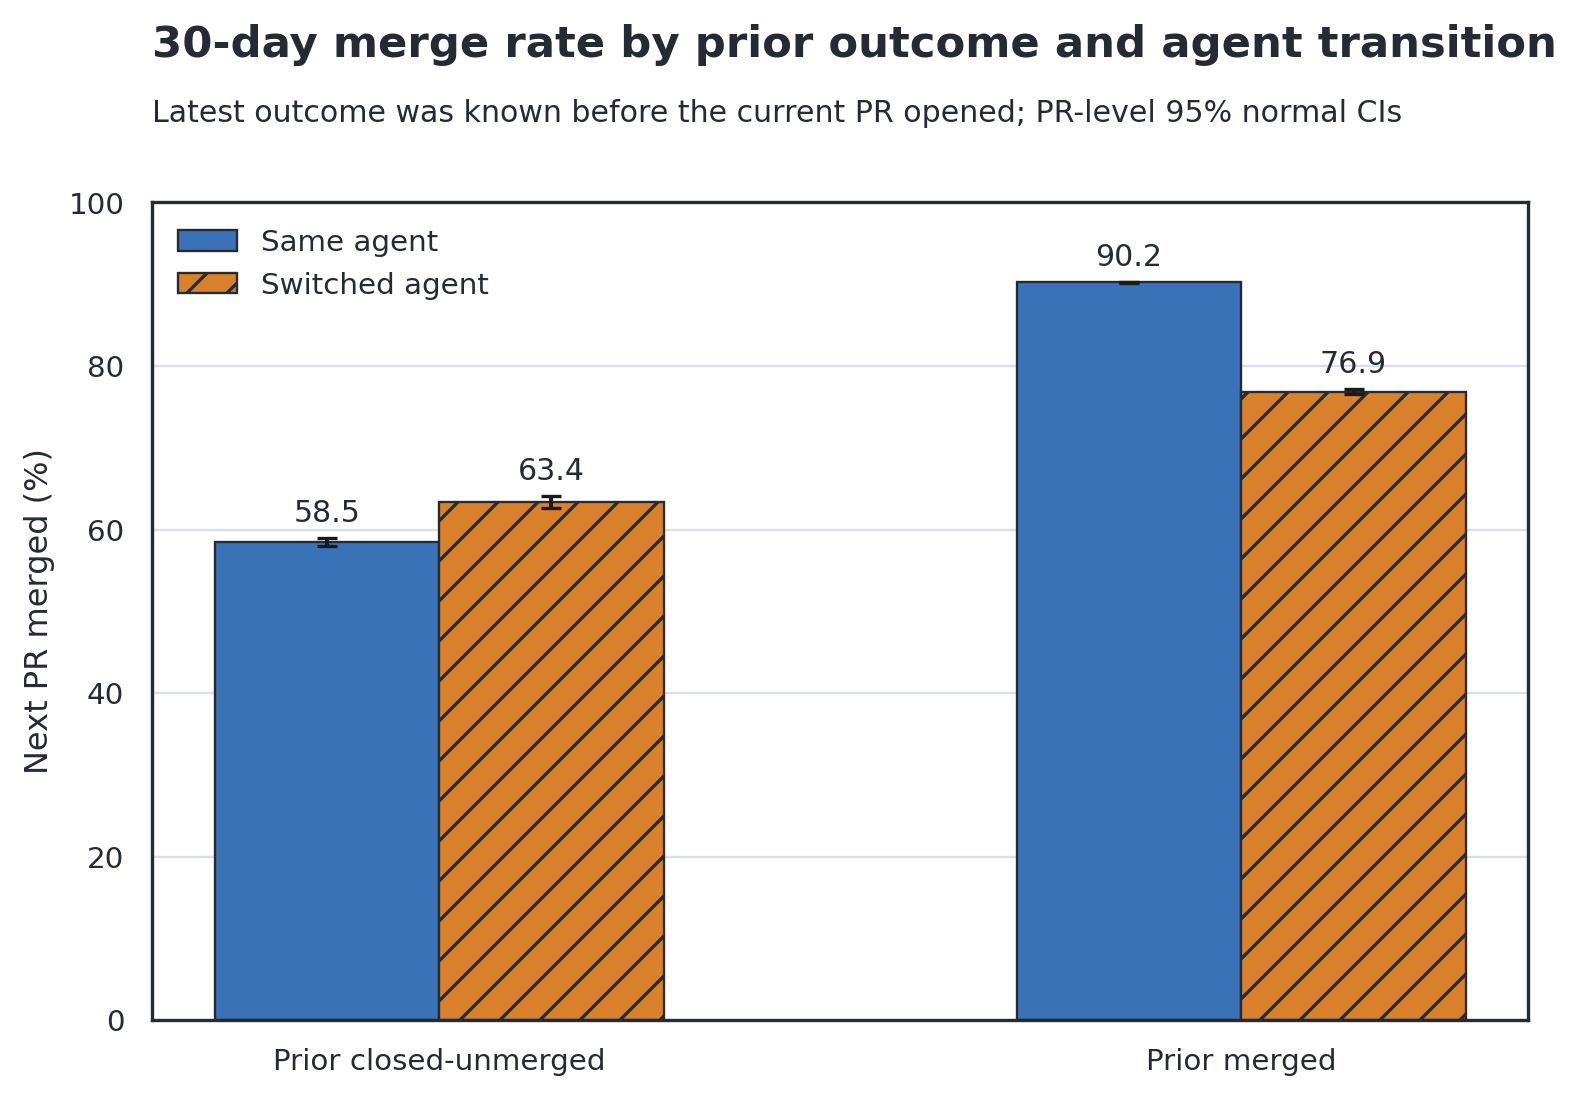

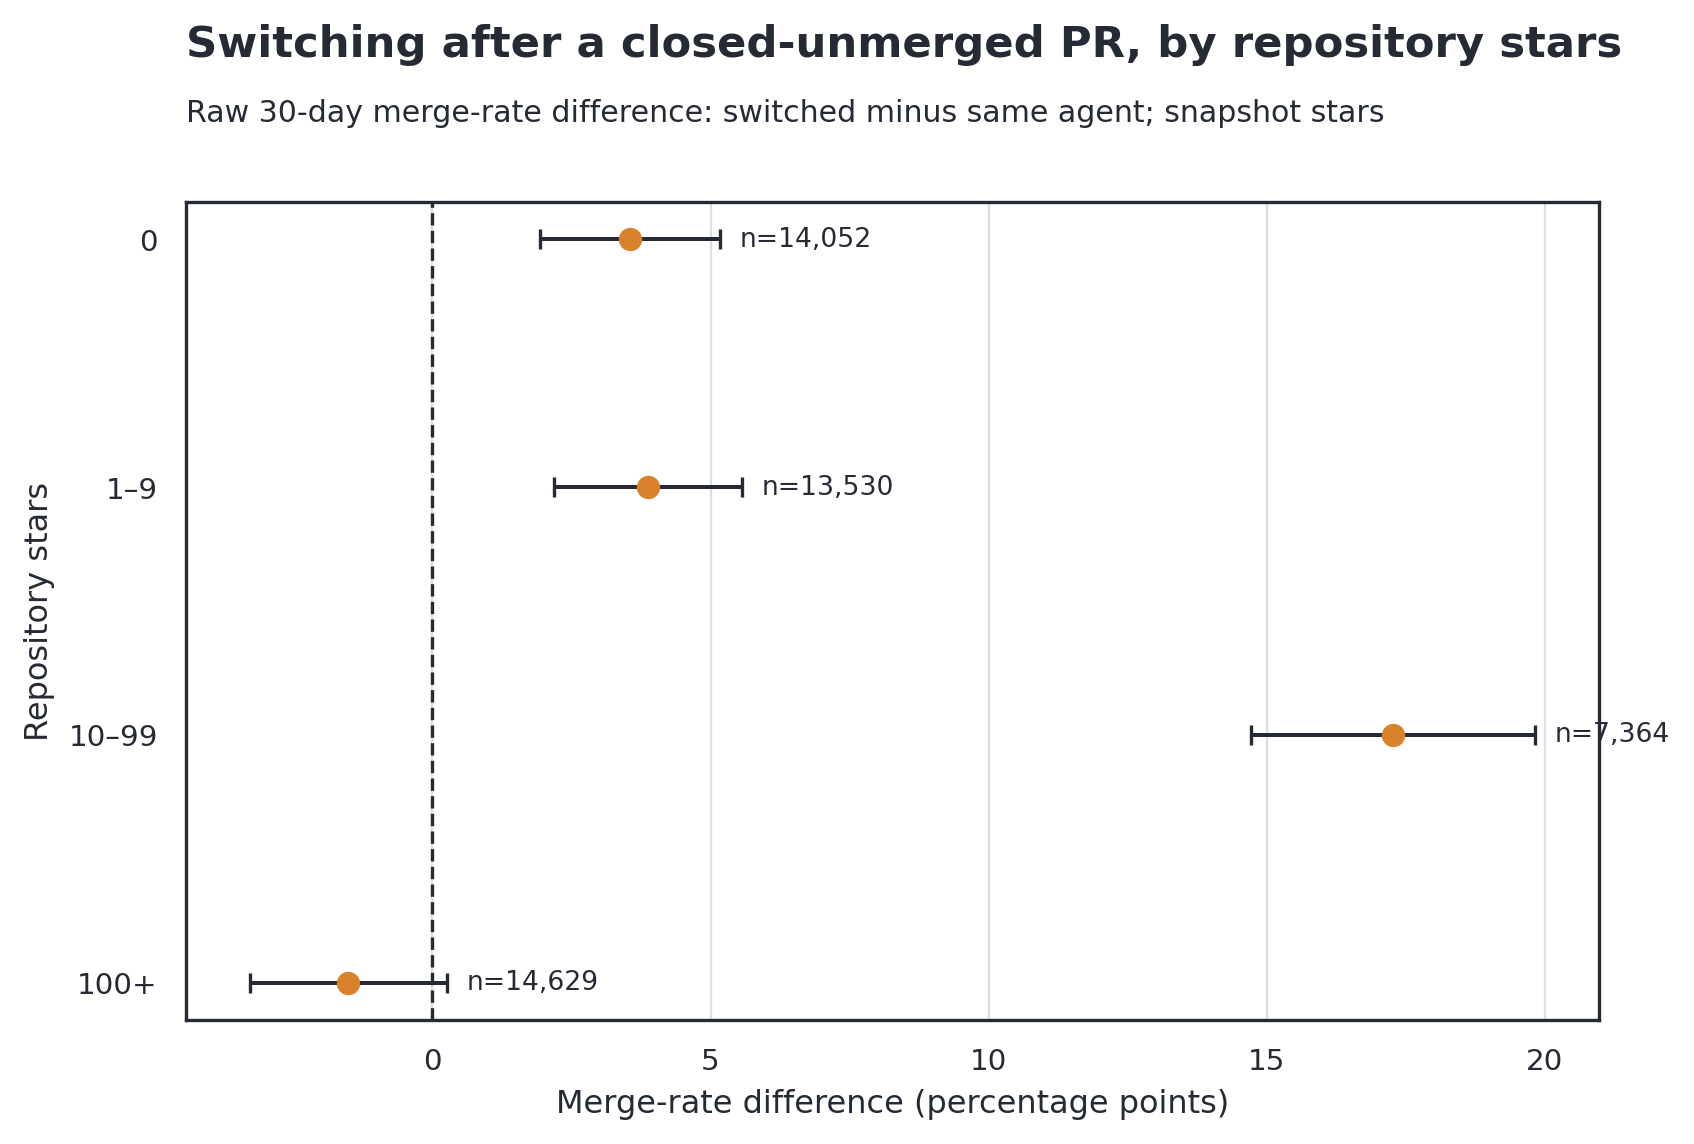

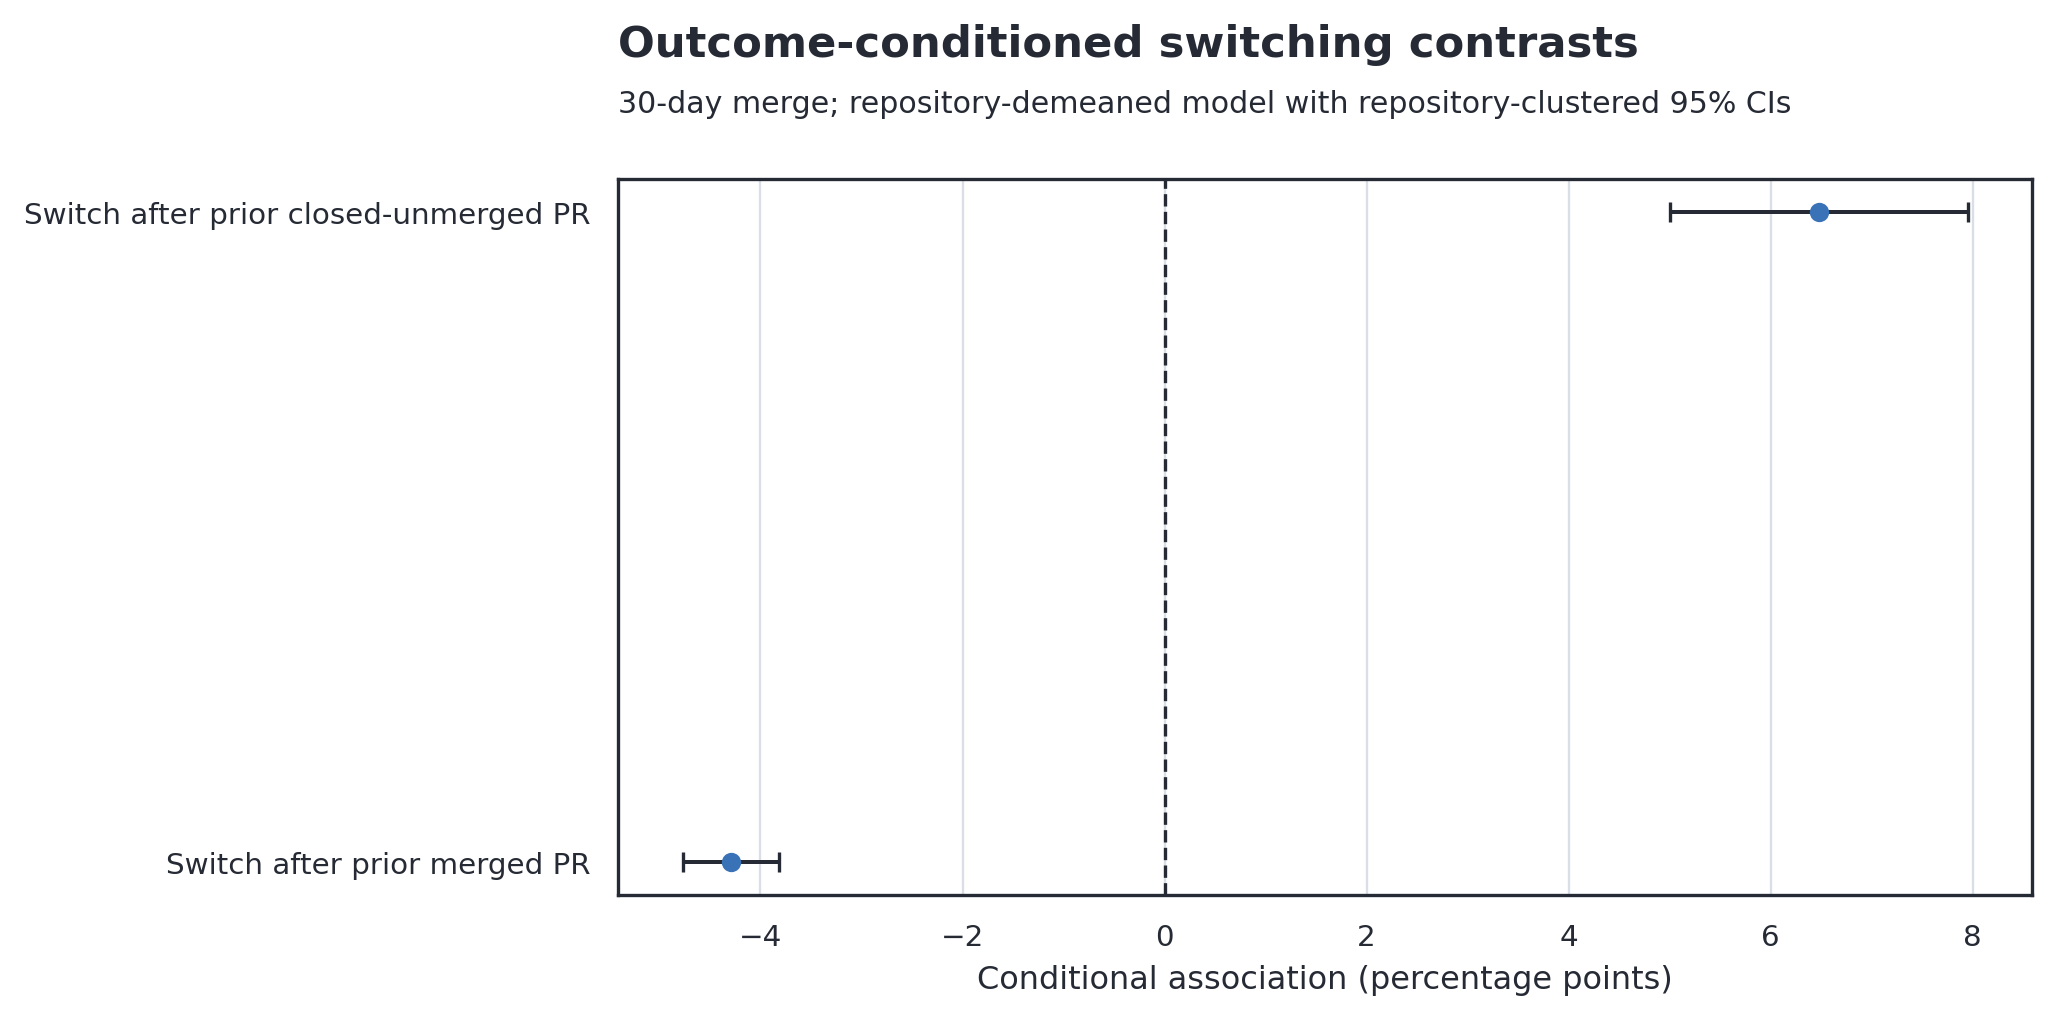

In [5]:
rates = pd.read_csv(TABLES / "rq3_recovery_rates.csv")
heterogeneity = pd.read_csv(TABLES / "rq3_star_heterogeneity.csv")
model = pd.read_csv(TABLES / "rq3_within_repo_lpm.csv")
display(rates[["prior_outcome", "transition_type", "n", "merge_rate"]])
display(heterogeneity)
display(model.loc[model["term"].isin([
    "switched", "switched_after_prior_merged"
])])
display(Image(filename=str(FIGURES / "rq3_recovery_crossover.png")))
display(Image(filename=str(FIGURES / "rq3_switching_heterogeneity.png")))
display(Image(filename=str(FIGURES / "rq2_adjusted_switching_contrasts.png")))

The association is heterogeneous and disappears in the 100+ star stratum. That is a
useful boundary condition and a warning that long-tail repository composition may
drive the aggregate result. Repository-demeaned estimates reduce stable between-repo
differences but remain non-causal.

## Takeaways

1. Keep the paper to three RQs and make outcome-conditioned switching the spine.
2. Treat repository maturity as a first-class boundary condition.
3. Before any causal language, add task/complexity controls from AIDev-pop, agent-pair
   sensitivity, high-volume-repository robustness, and manually validate sampled
   transition episodes.